# Solve Model

## Hatano-Nelson model

10.1103/PhysRevX.13.021007

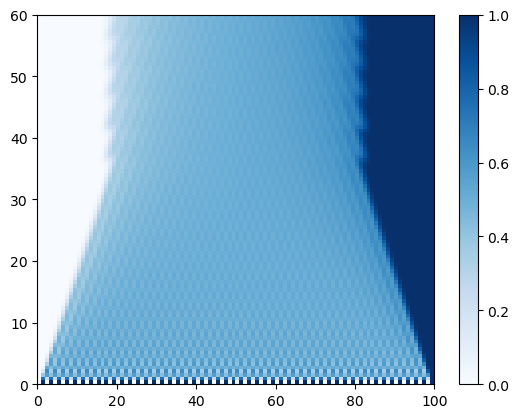

In [6]:
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.8
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import xx_evolve
res = xx_evolve(L, ham, "01"*(L//2), np.linspace(0, 60, 100))

import matplotlib.pyplot as plt
plt.imshow(res, aspect='auto', cmap='Blues', origin='lower', extent=(0, 100, 0, 60))
plt.colorbar()

other observables

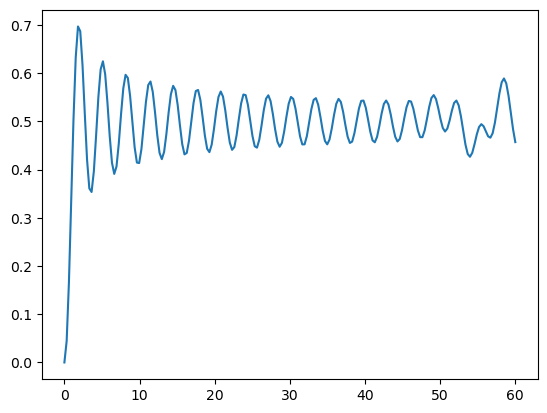

In [2]:
# particle number
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 60, 200)
result = []
for s in state.evolve(h, tlist):
    result.append(s.particle_number(L//2))
res = np.array(result)

import matplotlib.pyplot as plt
plt.plot(tlist, res)

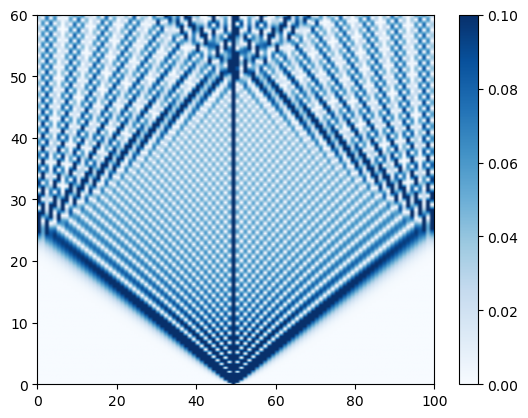

In [3]:
# correlation
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 60, 500)
result = []
for s in state.evolve(h, tlist):
    result.append(s.correlation())  
    # default is the correlation w.r.t. the middle site
res = np.abs(result)

import matplotlib.pyplot as plt
plt.imshow(res, aspect='auto', cmap='Blues', origin='lower', extent=(0, 100, 0, 60))
plt.clim(0,0.1)
plt.colorbar()

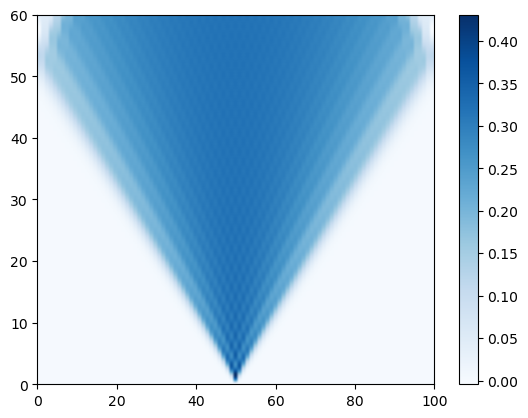

In [ ]:
# particle number current
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 60, 500)
result = []
for s in state.evolve(h, tlist):
    obst = [np.imag(sum(s.U[l, :] * s.U[l+1, :].conj())) for l in range(L-1)]
    result.append(obst)
    # default is the correlation w.r.t. the middle site
res = np.array(result)

import matplotlib.pyplot as plt

plt.imshow(res, aspect='auto', cmap='Blues', origin='lower', extent=(0, 100, 0, 60))
plt.colorbar()

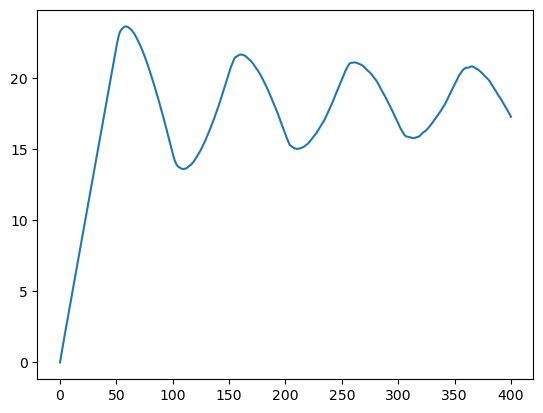

In [5]:
# entangement
import quante as qt
import numpy as np

op = qt.generate.operas
builder = op.SpinBuilder()
L = 100
J, γ = 1, 0.
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

from quante.solvable_models.gaussian_state import SlaterState
model = ham.jw_transfer()
h = model.single_particle_ham(L)
state = SlaterState.from_product_state("01"*(L//2))
tlist = np.linspace(0, 400, 500)
result = []
for s in state.evolve(h, tlist):
    result.append(s.entanglement(range(L//2)))  
    # default is the correlation w.r.t. the middle site
res = np.array(result)

import matplotlib.pyplot as plt
plt.plot(tlist, res)

In [6]:
# reduced density matrix
import quante as qt
import numpy as np

op = qt.generate.operas

L = 100
J, γ = 1, 0.

builder = op.SpinBuilder()
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

model = ham.jw_transfer()
h = model.single_particle_ham(L)
state_str = "10"*(L//2) + "1"*(L%2)

from quante.solvable_models.gaussian_state import SlaterState
state = SlaterState.from_product_state(state_str, spin=True)
tlist = np.linspace(0, 60, 100)
result = []
s = state
for s in state.evolve(h, tlist):
    pass

s.reduced_density_matrix([50,51])

array([[0.25991372+0.j        , 0.        +0.j        , 0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.2831486 +0.j        , 0.        +0.03526381j, 0.        +0.j        ],
       [0.        +0.j        , 0.        -0.03526381j, 0.22098368-0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        , 0.        +0.j        , 0.235954  +0.j        ]])

In [7]:
# reduced density matrix —— banchmark
import quante as qt
import numpy as np

op = qt.generate.operas

L = 10
J, γ = 1, 0.

builder = op.SpinBuilder()
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

model = ham.jw_transfer()
h = model.single_particle_ham(L)
state_str = "10"*(L//2) + "1"*(L%2)

from quante.solvable_models.gaussian_state import SlaterState
state = SlaterState.from_product_state(state_str, spin=True)
tlist = np.linspace(0, 60, 100)
result = []
s = state
for s in state.evolve(h, tlist):
    pass

show(s.reduced_density_matrix([4,5]))

# now use ed
state = qt.generate.state.product_state(state_str)
basis = qt.generate.basis.spin_basis(L=L)
mat = ham.to_matrix(basis)
psi2 = qt.linalg.expm(mat, -1j*60) @ state

rhoA2 = qt.linalg.partial_trace(psi2, [2]*L, [4,5])
show(rhoA2)

s.reduced_density_matrix([4, 5]): 
   [[ 0.20951411+0.j          0.        +0.j          0.        +0.j          0.        +0.j        ]
    [ 0.        +0.j          0.1004162 +0.j         -0.        +0.06602575j  0.        +0.j        ]
    [ 0.        +0.j         -0.        -0.06602575j  0.48055557-0.j          0.        +0.j        ]
    [ 0.        +0.j          0.        +0.j          0.        +0.j          0.20951411+0.j        ]]
rhoA2: [[ 0.20951411+0.j          0.        +0.j          0.        -0.j         -0.        -0.j        ]
        [ 0.        -0.j          0.1004162 +0.j         -0.        +0.06602575j -0.        +0.j        ]
        [ 0.        +0.j         -0.        -0.06602575j  0.48055557+0.j         -0.        -0.j        ]
        [-0.        +0.j         -0.        -0.j         -0.        +0.j          0.20951411+0.j        ]]


## Ising Chain

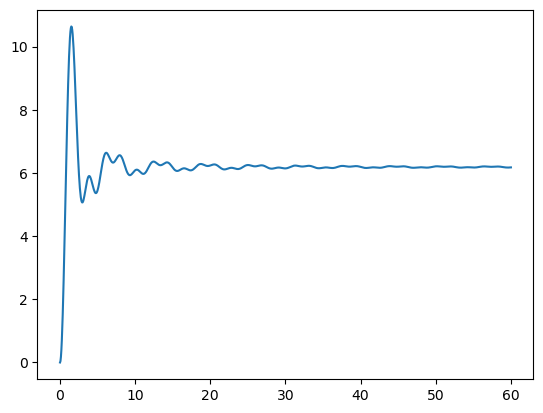

In [7]:
import quante as qt
import numpy as np
from quante.solvable_models import gaussian_state
L = 100
builder = qt.generate.operas.SpinBuilder()
for i in range(L-1):
    builder += "xx", [i+1, i], 1.
for i in range(L):
    builder += "z", [i], 1.
ham = builder.build()
tlist = np.linspace(0, 60, 1000)
result = gaussian_state.ising_evolve(
    L, ham, '0'*L, tlist
)
plt.plot(tlist, result)

## 算符代数的一些工具

目前主要是费米子的算符代数，后续会添加玻色子算符代数的内容。

In [ ]:
import quante as qt
op = qt.generate.operas

builder = op.FermionBuilder()
builder += '-'*6 + '+'*6, list(range(1, 7))+list(range(1, 7)), 1.
ham = builder.build()
ham

FermionOper at 0x17e8b32edb0, 
|   -     -     -     -     -     -     +     +     +     +     +     +       coef. |
|-----------------------------------------------------------------------------------|
|   1     2     3     4     5     6     1     2     3     4     5     6       1.000 |

In [ ]:
ham.normal_ordering()

FermionOper at 0x17e8b32ede0, 
|   I       coef. |   +     -       coef. |   +     +     -     -       coef. |
|-----------------|-----------------------|-----------------------------------|
|   0      -1.000 |   1     1       1.000 |   1     2     1     2       1.000 |
|                 |   2     2       1.000 |   1     3     1     3       1.000 |
|                 |   3     3       1.000 |   2     3     2     3       1.000 |
|                 |   4     4       1.000 |   1     4     1     4       1.000 |
|                 |   5     5       1.000 |   2     4     2     4       1.000 |
|                 |   6     6       1.000 |   3     4     3     4       1.000 |
|                                         |   1     5     1     5       1.000 |
|                                         |   2     5     2     5       1.000 |
|                                         |   3     5     3     5       1.000 |
|                                         |   4     5     4     5       1.000 |
|        

# 

In [ ]:
# JW transformation
import quante as qt

op = qt.generate.operas
builder = op.SpinBuilder()
L = 10
J, γ = 1, 0.0
for i in range(L-1):
    builder += "+-", [i+1, i], (J+γ)/2
    builder += "+-", [i, i+1], (J-γ)/2
ham = builder.build()

ham.jw_transfer()

FermionOper at 0x17e8e966870, 
|   +     -       coef. |
|-----------------------|
|   1     0      -0.500 |
|   0     1      -0.500 |
|   2     1      -0.500 |
|   1     2      -0.500 |
|   3     2      -0.500 |
|   2     3      -0.500 |
|   4     3      -0.500 |
|   3     4      -0.500 |
|   5     4      -0.500 |
|   4     5      -0.500 |
|   6     5      -0.500 |
|   5     6      -0.500 |
|   7     6      -0.500 |
|   6     7      -0.500 |
|   8     7      -0.500 |
|   7     8      -0.500 |
|   9     8      -0.500 |
|   8     9      -0.500 |